# 09 — Pupil Mimicry Feasibility Spike

**This is a spike, not a metric.** The goal is to decide whether webcam video can support pupil-mimicry analysis at all, and write a go/no-go recommendation. We do **not** build the mimicry metric in this notebook.

## What "pupil mimicry" actually requires

Pupil mimicry in the trust literature is the phenomenon where one person's **pupil** dilation is followed by the observer's pupil dilating. Key facts:

- The **iris** (the colored part) has a biologically fixed diameter of about **11.7 mm** in adults. It does not change size.
- The **pupil** (the black center) does change size, responding to light (fast, large) and to arousal/cognitive load (slow, small — about **0.1–0.5 mm** under constant lighting).
- Pupil mimicry amplitudes are on the low end of that range, often well under **0.3 mm**.

**MediaPipe Face Mesh gives us iris landmarks (468–477), not pupil landmarks.** There is no pupil detector in MediaPipe. So this spike is really asking: *can we get close enough with iris landmarks as a proxy or geometric ruler?*

## What this notebook does

1. Re-runs MediaPipe on the video to pull all 10 iris landmarks per frame (the shared pipeline only saves the 2 iris centers).
2. Computes per-frame iris **diameter** two ways (max perimeter-to-perimeter distance; 2× mean center-to-perimeter distance).
3. Since iris diameter is biologically constant, any *variance* in this signal is noise (landmark jitter + subject-distance-to-camera changes).
4. Uses the known 11.7 mm iris diameter as a ruler to convert that noise into millimeters.
5. Compares the noise floor to the 0.1–0.5 mm amplitude of real pupil-response signals.
6. Writes a go/no-go recommendation.

**Inputs:** the same video used for the merged parquet, plus the meta sidecar for dimensions and fps.  
**Outputs:** plots, noise numbers, written recommendation.

In [1]:
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import mediapipe as mp
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 50)

## Config

In [2]:
VIDEO_STEM = "sample"

SKIP_FRAMES = 5              # must match the pipeline setting for sample alignment
IRIS_DIAMETER_MM = 11.7      # adult human iris horizontal diameter, biological constant

PROJECT_ROOT = Path("..").resolve()
DATA_DIR = PROJECT_ROOT / "data"
META_PATH = DATA_DIR / f"{VIDEO_STEM}_merged.meta.json"

meta = pd.read_json(META_PATH, typ="series")
VIDEO_PATH = meta["video_path"]
WIDTH = int(meta["width"])
HEIGHT = int(meta["height"])
FPS = float(meta["effective_fps"])
frame_duration_s = 1.0 / FPS

print(f"Video:       {VIDEO_PATH}")
print(f"Dimensions:  {WIDTH} x {HEIGHT}")
print(f"Effective fps: {FPS}")

Video:       /Users/atharvumap/Documents/Projects/PyfeatTesting/sample.mp4
Dimensions:  1280 x 720
Effective fps: 6.0


## 1. Re-run MediaPipe, extract all 10 iris landmarks

**Why re-run:** `00_pipeline.ipynb` only stores the two iris *centers* (468, 473). For diameter we also need the four perimeter points per iris (469–472 left, 474–477 right). We run a minimal MediaPipe pass just for those.

**Landmark layout:**
- Left iris: `468` (center), `469`/`470`/`471`/`472` (perimeter at ~90° intervals).
- Right iris: `473` (center), `474`/`475`/`476`/`477` (perimeter at ~90° intervals).

**What we extract per frame:** x/y for all 10 landmarks in **pixel coordinates** (not normalized), so distance math is in pixels.

**Takes a minute or two.** Less heavy than the full pipeline because we only need Face Mesh, not Pose or Hands.

In [3]:
L_IRIS = [468, 469, 470, 471, 472]  # center + 4 perimeter
R_IRIS = [473, 474, 475, 476, 477]

def extract_iris_landmarks(video_path: str, skip_frames: int = 1, width: int = 1280, height: int = 720):
    mp_face = mp.solutions.face_mesh.FaceMesh(
        static_image_mode=False, max_num_faces=1,
        refine_landmarks=True, min_detection_confidence=0.5,
    )
    cap = cv2.VideoCapture(video_path)
    rows = []
    frame_idx = 0
    try:
        while True:
            ok, frame = cap.read()
            if not ok:
                break
            if frame_idx % skip_frames != 0:
                frame_idx += 1
                continue
            rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            res = mp_face.process(rgb)
            row = {"frame": frame_idx, "timestamp": frame_idx / (FPS * skip_frames / skip_frames)}
            if res.multi_face_landmarks:
                lms = res.multi_face_landmarks[0].landmark
                for idx in L_IRIS + R_IRIS:
                    row[f"lm{idx}_x"] = lms[idx].x * width
                    row[f"lm{idx}_y"] = lms[idx].y * height
            rows.append(row)
            frame_idx += 1
    finally:
        cap.release()
        mp_face.close()
    df = pd.DataFrame(rows)
    df["timestamp"] = df["frame"] / (FPS * skip_frames)  # seconds in real time
    return df

iris = extract_iris_landmarks(VIDEO_PATH, skip_frames=SKIP_FRAMES, width=WIDTH, height=HEIGHT)
print(f"Extracted {len(iris)} frames, {iris.notna().all(axis=1).sum()} with full iris detection.")
iris.head(3)

I0000 00:00:1777006696.290825 14910097 gl_context.cc:357] GL version: 2.1 (2.1 Metal - 89.3), renderer: Apple M4 Pro
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1777006696.292838 14910243 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1777006696.299133 14910245 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
/Users/atharvumap/Documents/Projects/PyfeatTesting/.venv/lib/python3.11/site-packages/google/protobuf/symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '


Extracted 165 frames, 165 with full iris detection.


,frame,timestamp,lm468_x,lm468_y,lm469_x,lm469_y,lm470_x,lm470_y,lm471_x,lm471_y,lm472_x,lm472_y,lm473_x,lm473_y,lm474_x,lm474_y,lm475_x,lm475_y,lm476_x,lm476_y,lm477_x,lm477_y
0,0,0.000000,584.445686,381.177177,594.711380,380.467615,584.062462,372.601233,574.173203,381.863093,584.780388,389.766126,689.684525,378.747182,699.475937,378.790655,689.864349,370.009060,679.891663,378.634830,689.556122,387.478137
1,5,0.166667,588.614845,381.750827,598.534241,381.238718,588.399925,373.261399,578.622894,382.254095,588.772621,390.246863,694.375534,379.711704,704.616852,379.709601,694.448013,371.082244,684.172668,379.653339,694.327927,388.334298
2,10,0.333333,591.001778,382.821822,600.996437,382.387648,590.932770,374.106274,580.949402,383.227329,591.018028,391.538486,697.511139,381.889830,707.614517,382.033424,697.835770,373.481984,687.402191,381.669846,697.210388,390.261669


## 2. Compute iris diameter per frame

Two estimates for robustness:

- **`d_span`** — the max Euclidean distance between any pair of the 4 perimeter points. This is the actual diameter measurement.
- **`d_radius2`** — `2 × mean(distance from center to perimeter points)`. Less sensitive to single-landmark noise because it averages four measurements. Should be similar to `d_span`.

Both in **pixels** at the frame's native resolution.

We compute both for left and right eye, then average across eyes.

In [4]:
def iris_diameter(df, center_idx, perim_indices):
    cx = df[f"lm{center_idx}_x"]; cy = df[f"lm{center_idx}_y"]
    perim = [(df[f"lm{i}_x"], df[f"lm{i}_y"]) for i in perim_indices]

    # d_span = max pairwise distance among perimeter points
    dists = []
    for i in range(len(perim)):
        for j in range(i+1, len(perim)):
            dx = perim[i][0] - perim[j][0]; dy = perim[i][1] - perim[j][1]
            dists.append(np.sqrt(dx*dx + dy*dy))
    d_span = pd.concat(dists, axis=1).max(axis=1)

    # d_radius2 = 2 * mean(center->perim distance)
    rads = []
    for px, py in perim:
        dx = px - cx; dy = py - cy
        rads.append(np.sqrt(dx*dx + dy*dy))
    d_radius2 = 2 * pd.concat(rads, axis=1).mean(axis=1)

    return d_span, d_radius2

lspan, lrad2 = iris_diameter(iris, 468, [469, 470, 471, 472])
rspan, rrad2 = iris_diameter(iris, 473, [474, 475, 476, 477])

iris["L_d_span"] = lspan; iris["L_d_rad2"] = lrad2
iris["R_d_span"] = rspan; iris["R_d_rad2"] = rrad2
iris["diam_px"] = (lspan + rspan) / 2   # primary measure
iris["diam_rad2_px"] = (lrad2 + rrad2) / 2

print(iris[["L_d_span", "R_d_span", "diam_px", "diam_rad2_px"]].describe().round(2))

       L_d_span  R_d_span  diam_px  diam_rad2_px
count    165.00    165.00   165.00        165.00
mean      19.79     19.99    19.89         18.34
std        1.05      1.00     0.96          0.86
min       16.62     16.91    16.79         15.42
25%       19.32     19.44    19.47         17.91
50%       19.94     20.20    20.12         18.46
75%       20.42     20.70    20.48         18.92
max       22.28     22.13    21.51         19.83


## 3. Plot iris diameter over time

**Expectation:** a *roughly flat* line. Real iris diameter is biologically fixed. Any slow drift is usually the subject moving closer/farther from the camera (perspective scaling). Any fast noise is landmark jitter.

**What variance in this signal means:** none of it is real biological pupil response — we're measuring iris not pupil. The variance is our **noise floor**. Any pupil-response signal we'd want to detect has to sit above this floor.

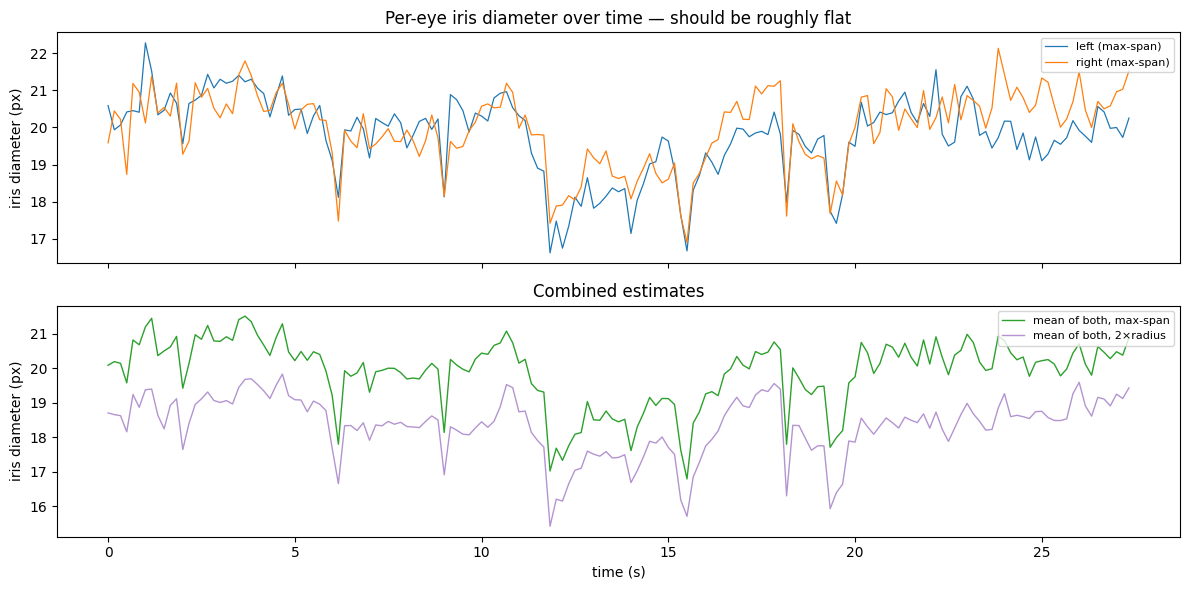

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
t = iris["timestamp"].to_numpy()

axes[0].plot(t, iris["L_d_span"], color="tab:blue", label="left (max-span)", lw=0.9)
axes[0].plot(t, iris["R_d_span"], color="tab:orange", label="right (max-span)", lw=0.9)
axes[0].set_ylabel("iris diameter (px)")
axes[0].set_title("Per-eye iris diameter over time — should be roughly flat")
axes[0].legend(loc="upper right", fontsize=8)

axes[1].plot(t, iris["diam_px"], color="tab:green", label="mean of both, max-span", lw=1.0)
axes[1].plot(t, iris["diam_rad2_px"], color="tab:purple", label="mean of both, 2×radius", lw=1.0, alpha=0.7)
axes[1].set_xlabel("time (s)")
axes[1].set_ylabel("iris diameter (px)")
axes[1].legend(loc="upper right", fontsize=8)
axes[1].set_title("Combined estimates")

plt.tight_layout()
plt.show()

## 4. Noise floor — frame-to-frame std in pixels

**What this measures:** the spread of our diameter estimate when nothing real is changing. Because iris diameter is biologically constant, this is a pure noise measurement.

**Two views:**
- **Global std** — total spread across the whole video. Inflated by slow perspective drift as the subject moves.
- **Frame-to-frame std** — std of `diff(diameter)`. Captures only fast, frame-level jitter (the purely-noise component); slow drift cancels out in the diff.

We use frame-to-frame std as the clean noise estimate.

In [6]:
diam_px = iris["diam_px"].dropna()
mean_px = float(diam_px.mean())
global_std_px = float(diam_px.std())
f2f_std_px = float(diam_px.diff().std())  # frame-to-frame noise

print(f"mean iris diameter:         {mean_px:.2f} px")
print(f"global std:                 {global_std_px:.3f} px  ({100*global_std_px/mean_px:.1f}% of mean)")
print(f"frame-to-frame noise std:   {f2f_std_px:.3f} px  ({100*f2f_std_px/mean_px:.1f}% of mean)")

mean iris diameter:         19.89 px
global std:                 0.960 px  (4.8% of mean)
frame-to-frame noise std:   0.655 px  (3.3% of mean)


## 5. Convert to millimeters (iris as ruler)

**How:** adult human iris horizontal diameter is ~11.7 mm and biologically constant, so:

$$\text{mm per pixel} = \frac{11.7}{\text{mean iris diameter in pixels}}$$

Then any pixel measurement (including the noise std) can be converted to mm.

This is the same approach commercial pupillometry uses — the iris is the known-size reference.

**Caveat:** perspective scaling as the subject moves closer/farther changes the mm-per-pixel ratio frame to frame. Over a 2-second interval with a seated subject this is negligible; over a long video or with lots of motion it isn't.

In [7]:
mm_per_px = IRIS_DIAMETER_MM / mean_px
global_std_mm = global_std_px * mm_per_px
f2f_std_mm = f2f_std_px * mm_per_px

# Minimum-detectable change, using a conservative 2-sigma rule
min_detectable_mm = 2 * f2f_std_mm

EXPECTED_PUPIL_RESPONSE_MM = 0.5       # upper end of arousal-driven dilation under constant light
EXPECTED_MIMICRY_MM = 0.3              # mimicry amplitude (observer following)

print(f"mm per pixel:                  {mm_per_px:.4f}")
print(f"global std:                    {global_std_mm:.3f} mm")
print(f"frame-to-frame noise std:      {f2f_std_mm:.3f} mm")
print(f"minimum detectable (2σ):       {min_detectable_mm:.3f} mm")
print()
print(f"expected pupil arousal signal: ~{EXPECTED_PUPIL_RESPONSE_MM:.2f} mm")
print(f"expected pupil mimicry:        ~{EXPECTED_MIMICRY_MM:.2f} mm")

mm per pixel:                  0.5883
global std:                    0.565 mm
frame-to-frame noise std:      0.385 mm
minimum detectable (2σ):       0.770 mm

expected pupil arousal signal: ~0.50 mm
expected pupil mimicry:        ~0.30 mm


## 6. Signal-to-noise verdict

**The critical ratio:** `expected_signal / noise_floor`. If this is below ~2, we can't reliably detect the signal even once, let alone track mimicry dynamics.

Remember: even if this calculation were favorable, **we're measuring iris, not pupil.** The pupil sits inside the iris and MediaPipe doesn't detect it. For actual pupil size you need either (a) enough resolution to detect the pupil-iris boundary by contrast, or (b) an IR imaging setup where the pupil appears dark against a bright iris.

In [8]:
snr_arousal = EXPECTED_PUPIL_RESPONSE_MM / f2f_std_mm if f2f_std_mm > 0 else float("inf")
snr_mimicry = EXPECTED_MIMICRY_MM / f2f_std_mm if f2f_std_mm > 0 else float("inf")

print(f"SNR (arousal signal / noise):  {snr_arousal:.2f}")
print(f"SNR (mimicry signal / noise):  {snr_mimicry:.2f}")
print()
if snr_mimicry < 2:
    print("➜ Mimicry signal is BELOW the noise floor on this setup.")
elif snr_mimicry < 5:
    print("➜ Mimicry signal is detectable but marginal — heavy averaging/denoising needed.")
else:
    print("➜ Mimicry signal should be resolvable with this setup.")

SNR (arousal signal / noise):  1.30
SNR (mimicry signal / noise):  0.78

➜ Mimicry signal is BELOW the noise floor on this setup.


## 7. Recommendation (fill in after running the cells above)

Template — replace the bracketed bits with the numbers from your run.

---

### Recommendation for the lab

**Webcam-based pupil mimicry from this pipeline: [NOT VIABLE / MARGINAL / VIABLE]**

**Evidence from this video (`sample.mp4`, 1280×720 @ 30 fps, head-and-shoulders framing):**
- Mean iris diameter in pixels: `[fill]`
- Frame-to-frame iris-diameter noise: `[fill]` px ≈ `[fill]` mm
- Minimum detectable change (2σ): `[fill]` mm
- Expected pupil-mimicry signal: ~0.3 mm
- Achieved SNR for mimicry: `[fill]`

**Fundamental limitation (independent of noise floor):** MediaPipe Face Mesh provides **iris** landmarks, not **pupil** landmarks. Iris diameter is biologically fixed; pupil diameter is what actually varies with arousal/mimicry. Even with perfect landmarks, this pipeline cannot measure pupil size — only iris geometry.

**To actually measure pupil mimicry, the lab needs one of:**

1. **Dedicated IR eye tracker** — Tobii Pro Spectrum, Pupil Labs Core, SR Research EyeLink. These image the pupil in infrared where it appears as a dark-against-bright contrast boundary that's easy to segment. Typical precision: ~0.01 mm. Cost: USD $3k–$40k depending on model.
2. **High-resolution visible-light setup + custom pupil segmentation** — e.g. a ~4K camera zoomed on one eye at ≥60 fps, paired with a CNN pupil-boundary detector (DeepVOG, PupilNet). Precision ~0.05–0.1 mm under controlled lighting. Feasible as a build but non-trivial.
3. **Skip pupil mimicry** and focus on the metrics already in this repo (AU synchrony in Ticket 8, Duchenne synchrony, gaze synchrony) as behavioral proxies for the same underlying rapport construct.

**My suggestion:** option 3 unless pupil mimicry is a named deliverable. The other eight metrics in this repo cover the face/behavioral side of trust well; adding a dedicated eye-tracker is a significant equipment and data-collection commitment for one additional signal.

---

Edit the bracketed fields with your actual numbers before sharing.